# TRABAJO PRACTICO INTEGRAL N°1

## Integrantes:

**CRISTIAN DAMIAN FORTUNESKY BARRIOS**

**MATIAS DE VIVO**

## Actividad: Imagen obtenida mediante camara oscura

Este cuaderno resuelve un pipeline de mejora y restauracion para una imagen de camara oscura con degradaciones de bajo brillo, bajo contraste, rotacion, ruido y exceso de fondo no informativo.

El criterio metodologico sigue una secuencia de operaciones acotada:

1. recorte de region util;
2. rotacion para normalizar orientacion;
3. suavizado para atenuacion de ruido;
4. mejora local de contraste con CLAHE.


## Fundamento tecnico del enfoque

La imagen de camara oscura concentra informacion util en una zona pequena y de baja energia luminica. En este escenario, aplicar mejoras globales sobre todo el cuadro suele amplificar ruido en el fondo. Por eso se prioriza una estrategia por etapas:

- **Recorte**: reduce el dominio de procesamiento a la zona con senal util y evita que el fondo oscuro domine la estadistica de intensidad.
- **Rotacion**: corrige la orientacion del objeto para facilitar lectura visual y comparacion de resultados.
- **Suavizado mediana**: atenúa ruido impulsivo conservando bordes mejor que un promedio simple.
- **CLAHE en luminancia**: incrementa contraste local limitando sobre-amplificacion de ruido mediante `clipLimit`.

La combinacion busca maximizar visibilidad de la zona importante sin introducir artefactos agresivos.


In [1]:
from pathlib import Path

try:
    import cv2
except ImportError as e:
    raise RuntimeError(
        "OpenCV no esta disponible. Instala opencv-python-headless o agrega libGL.so.1 en el sistema."
    ) from e

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)

## Carga de imagen y utilidades

La ruta esperada para la actividad es `005/003 - LAB/img/img-camara-oscura.jpg`. Se agrega una busqueda alternativa por nombre de archivo dentro del repositorio para mantener reproducibilidad si cambia la ubicacion exacta.


In [2]:
def buscar_imagen_camara_oscura():
    candidatos = [
        Path('005/003 - LAB/img/img-camara-oscura.jpg'),
        Path('img-camara-oscura.jpg'),
        Path('005 - TFI_1/img-camara-oscura.jpg')
    ]
    for p in candidatos:
        if p.exists():
            return p

    for p in Path('.').rglob('img-camara-oscura.jpg'):
        return p

    raise FileNotFoundError('No se encontro la imagen img-camara-oscura.jpg en el repositorio.')


def cargar_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f'No se pudo abrir: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def mostrar(imagen, titulo, cmap=None):
    plt.figure()
    if cmap is None:
        plt.imshow(imagen)
    else:
        plt.imshow(imagen, cmap=cmap)
    plt.title(titulo)
    plt.axis('off')
    plt.show()


def mostrar_histograma_gris(imagen_rgb, titulo='Histograma en escala de grises'):
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    hist = cv2.calcHist([gris], [0], None, [256], [0, 256]).ravel()
    plt.figure(figsize=(8,3))
    plt.plot(hist)
    plt.title(titulo)
    plt.xlabel('Nivel de gris')
    plt.ylabel('Frecuencia')
    plt.show()

Imagen cargada desde: img\img-camara-oscura.jpg
Dimensiones: 1280x960


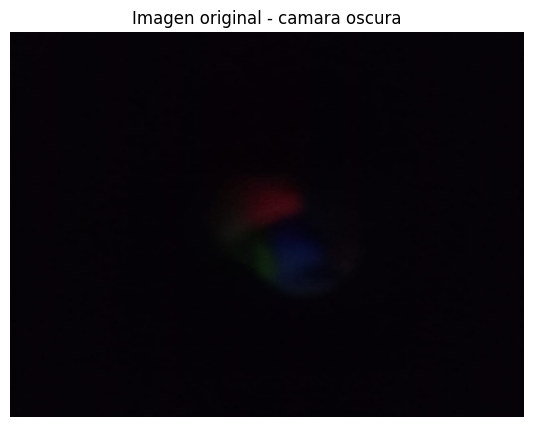

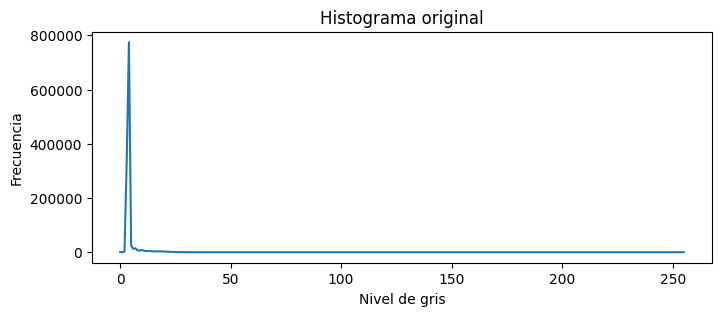

In [3]:
ruta_imagen = buscar_imagen_camara_oscura()
imagen_original = cargar_rgb(ruta_imagen)

print(f'Imagen cargada desde: {ruta_imagen}')
print(f'Dimensiones: {imagen_original.shape[1]}x{imagen_original.shape[0]}')

mostrar(imagen_original, 'Imagen original - camara oscura')
mostrar_histograma_gris(imagen_original, 'Histograma original')

## Diagnostico inicial cuantitativo

Se usan dos indicadores sobre escala de grises:

- **Brillo medio**: aproxima nivel de iluminacion global.
- **Desvio estandar**: aproxima contraste global.

Valores bajos en ambos indicadores son consistentes con la degradacion observada en la imagen de entrada.


In [4]:
gris_original = cv2.cvtColor(imagen_original, cv2.COLOR_RGB2GRAY)
brillo_medio_original = float(np.mean(gris_original))
contraste_original = float(np.std(gris_original))

print(f'Brillo medio original: {brillo_medio_original:.2f}')
print(f'Contraste (desvio estandar) original: {contraste_original:.2f}')

Brillo medio original: 4.30
Contraste (desvio estandar) original: 2.54


## Paso 1: Recorte de region util

Fundamento: el objeto de interes aparece como una isla de mayor intensidad sobre un fondo casi negro. Se segmenta una mascara en el canal V de HSV usando un umbral por percentil alto y se extrae la caja envolvente con margen.

Esta etapa reduce fondo inutil y evita que el histograma quede dominado por pixels oscuros del entorno.


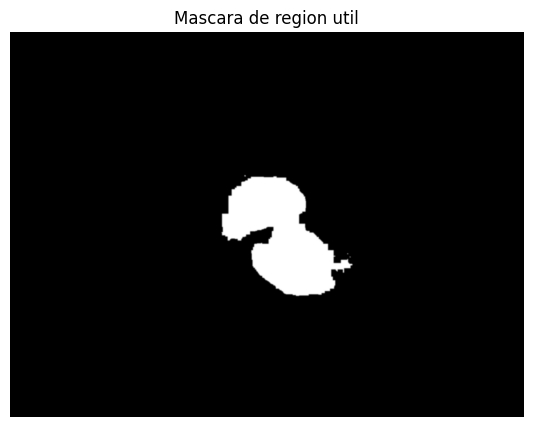

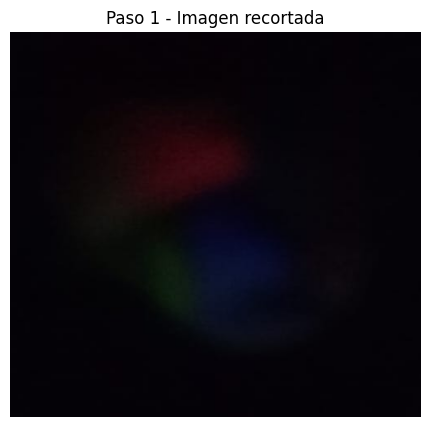

In [6]:

def recorte_region_util(imagen_rgb, percentil=96.0, margen=55, factor_expansion=1.18):
    hsv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2HSV)
    v = hsv[:, :, 2]

    umbral = np.percentile(v, percentil)
    mascara = (v >= umbral).astype(np.uint8) * 255

    kernel = np.ones((5, 5), np.uint8)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel, iterations=2)
    mascara = cv2.GaussianBlur(mascara, (5, 5), 0)

    ys, xs = np.where(mascara > 0)
    if len(xs) == 0 or len(ys) == 0:
        return imagen_rgb.copy(), mascara

    # Caja base detectada por máscara
    x1_base, x2_base = xs.min(), xs.max()
    y1_base, y2_base = ys.min(), ys.max()

    # Expansión alrededor del centro para recortar menos agresivo
    cx = (x1_base + x2_base) / 2.0
    cy = (y1_base + y2_base) / 2.0
    w = (x2_base - x1_base + 1) * factor_expansion
    h = (y2_base - y1_base + 1) * factor_expansion

    x1 = int(max(cx - w / 2 - margen, 0))
    x2 = int(min(cx + w / 2 + margen, imagen_rgb.shape[1]))
    y1 = int(max(cy - h / 2 - margen, 0))
    y2 = int(min(cy + h / 2 + margen, imagen_rgb.shape[0]))

    recorte = imagen_rgb[y1:y2, x1:x2]
    return recorte, mascara


# Uso recomendado con ajuste menos agresivo
imagen_recortada, mascara_roi = recorte_region_util(
    imagen_original,
    percentil=96.0,
    margen=55,
    factor_expansion=1.18
)

mostrar(mascara_roi, 'Mascara de region util', cmap='gray')
mostrar(imagen_recortada, 'Paso 1 - Imagen recortada')

## Paso 2: Rotacion de alineacion

Fundamento: la orientacion inclinada reduce legibilidad de la zona util. Primero se estima el angulo principal con minAreaRect y se aplica una rotacion afin alrededor del centro de la imagen recortada.

Para mantener reproducibilidad, el giro adicional de 180° se deja como parametro opcional (`FORZAR_FLIP_180`) y por defecto desactivado. Solo debe activarse si en una ejecucion concreta el sujeto queda invertido.


Angulo estimado para correccion: -19.77 grados
Flip 180 forzado: True


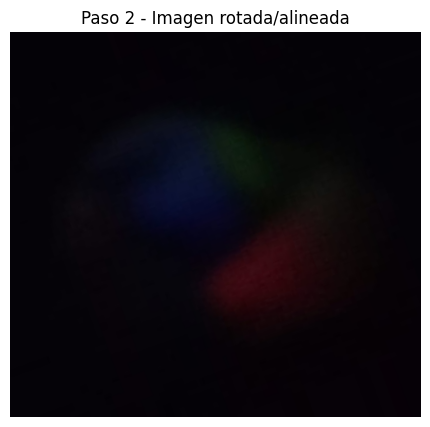

In [8]:
def estimar_angulo_principal(imagen_rgb):
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    umbral = np.percentile(gris, 97)
    binaria = (gris >= umbral).astype(np.uint8) * 255

    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contornos:
        return 0.0

    contorno = max(contornos, key=cv2.contourArea)
    rect = cv2.minAreaRect(contorno)
    angulo = rect[-1]

    if angulo < -45:
        angulo = 90 + angulo
    return float(angulo)


def rotar_imagen(imagen_rgb, angulo):
    h, w = imagen_rgb.shape[:2]
    centro = (w // 2, h // 2)
    matriz = cv2.getRotationMatrix2D(centro, angulo, 1.0)
    return cv2.warpAffine(imagen_rgb, matriz, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)


angulo_estimado = estimar_angulo_principal(imagen_recortada)
imagen_rotada = rotar_imagen(imagen_recortada, -angulo_estimado)

# Control explicito para este caso: evita que el sujeto quede cabeza para abajo.
FORZAR_FLIP_180 = True
if FORZAR_FLIP_180:
    imagen_rotada = rotar_imagen(imagen_rotada, 180)

print(f'Angulo estimado para correccion: {angulo_estimado:.2f} grados')
print(f'Flip 180 forzado: {FORZAR_FLIP_180}')
mostrar(imagen_rotada, 'Paso 2 - Imagen rotada/alineada')

## Paso 3: Suavizado para reduccion de ruido

Fundamento: en condiciones de baja iluminacion aparece ruido de sensor y compresion. Se usa filtro de mediana (`ksize=3`) por su capacidad de reducir ruido impulsivo sin borrar completamente los bordes de la region iluminada.


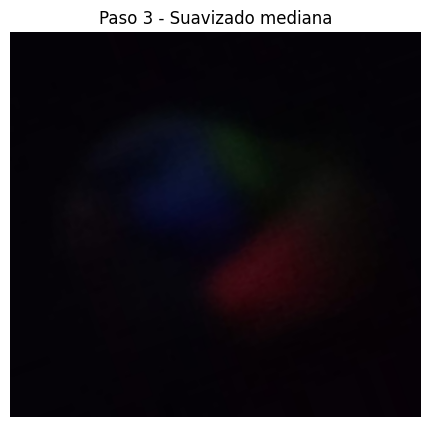

In [9]:
imagen_suavizada = cv2.medianBlur(imagen_rotada, 3)
mostrar(imagen_suavizada, 'Paso 3 - Suavizado mediana')

## Paso 4: Mejora de contraste con CLAHE

Fundamento: la ecualizacion adaptativa por bloques aumenta contraste local en zonas de baja dinamica. Para evitar sobreamplificacion de ruido se aplica sobre canal L del espacio LAB con `clipLimit` moderado.


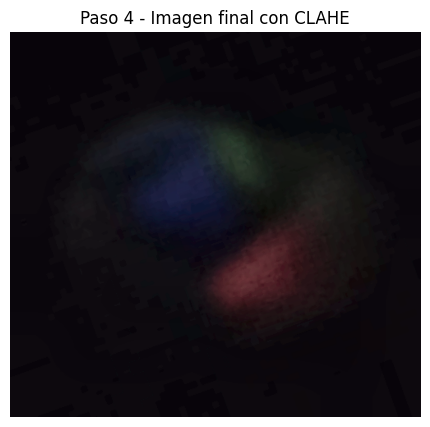

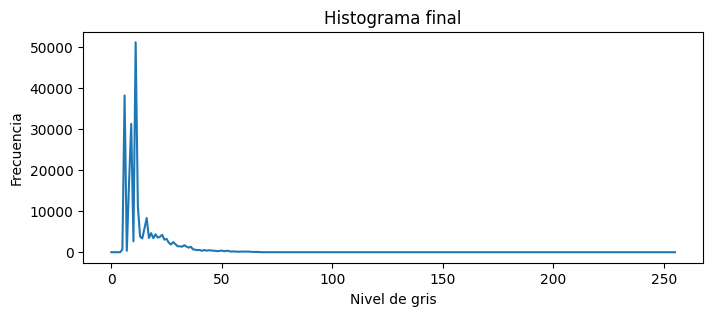

In [10]:
def aplicar_clahe_lab(imagen_rgb, clip_limit=2.0, tile=(8,8)):
    lab = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    l2 = clahe.apply(l)

    lab2 = cv2.merge([l2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)


imagen_final = aplicar_clahe_lab(imagen_suavizada, clip_limit=2.2, tile=(8,8))
mostrar(imagen_final, 'Paso 4 - Imagen final con CLAHE')
mostrar_histograma_gris(imagen_final, 'Histograma final')

## Estrategia alternativa y comparacion transversal

Para cumplir con la consigna de comparar estrategias, se agrega una segunda ruta de mejora sobre la misma imagen recortada y alineada.

- **Estrategia A (actual)**: mediana + CLAHE en LAB.
- **Estrategia B (alternativa)**: bilateral + correccion gamma + CLAHE en canal Y (YCrCb).

Luego se comparan con metricas objetivas y criterio visual para elegir la opcion final.


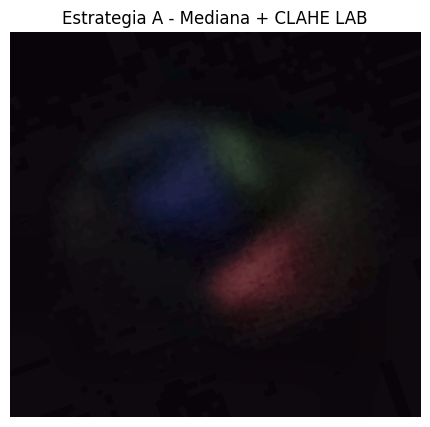

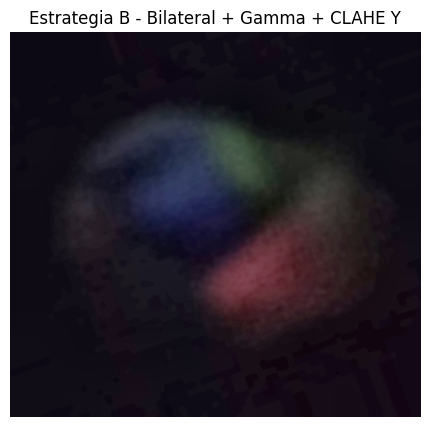

In [11]:
def correccion_gamma(imagen_rgb, gamma=1.25):
    inv = 1.0 / gamma
    tabla = np.array([(i / 255.0) ** inv * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(imagen_rgb, tabla)

def clahe_ycrcb(imagen_rgb, clip_limit=2.0, tile=(8, 8)):
    ycrcb = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    y2 = clahe.apply(y)
    return cv2.cvtColor(cv2.merge([y2, cr, cb]), cv2.COLOR_YCrCb2RGB)

# Estrategia A (ya construida)
imagen_estrategia_a = imagen_final.copy()

# Estrategia B: bilateral -> gamma -> CLAHE en Y
imagen_bilateral = cv2.bilateralFilter(imagen_rotada, d=7, sigmaColor=45, sigmaSpace=45)
imagen_gamma = correccion_gamma(imagen_bilateral, gamma=1.30)
imagen_estrategia_b = clahe_ycrcb(imagen_gamma, clip_limit=2.0, tile=(8, 8))

mostrar(imagen_estrategia_a, 'Estrategia A - Mediana + CLAHE LAB')
mostrar(imagen_estrategia_b, 'Estrategia B - Bilateral + Gamma + CLAHE Y')


## Seleccion de estrategia optima para Actividad 1

Se comparan indicadores complementarios entre una base comun y las dos variantes de mejora aplicadas sobre la misma ROI alineada:

- **Brillo medio** y **contraste global** (visibilidad general).
- **Varianza del Laplaciano** (nitidez estructural aproximada).
- **Entropia** (riqueza tonal util, evitando imagen lavada).

La referencia para puntuar es `imagen_base_comparable` (misma geometria que A/B, sin realce), evitando sesgo por recorte o rotacion al comparar contra la imagen original completa.


In [12]:
def metricas_calidad(imagen_rgb):
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    brillo = float(np.mean(gris))
    contraste = float(np.std(gris))
    nitidez = float(cv2.Laplacian(gris, cv2.CV_64F).var())

    hist = cv2.calcHist([gris], [0], None, [256], [0, 256]).ravel()
    p = hist / np.sum(hist)
    p = p[p > 0]
    entropia = float(-np.sum(p * np.log2(p)))
    return {'brillo': brillo, 'contraste': contraste, 'nitidez': nitidez, 'entropia': entropia}

# Base comparable: misma ROI/alineacion sin mejoras de contraste
imagen_base_comparable = imagen_rotada.copy()

m_base = metricas_calidad(imagen_base_comparable)
m_a = metricas_calidad(imagen_estrategia_a)
m_b = metricas_calidad(imagen_estrategia_b)

print('Metricas - Base comparable:', m_base)
print('Metricas - Estrategia A:', m_a)
print('Metricas - Estrategia B:', m_b)

pesos = {'brillo': 0.25, 'contraste': 0.30, 'nitidez': 0.30, 'entropia': 0.15}

def score_relativo(m_ref, m_cmp):
    # score > 1 indica mejora promedio ponderada respecto de referencia
    s = 0.0
    for k, w in pesos.items():
        if m_ref[k] == 0:
            continue
        s += w * (m_cmp[k] / m_ref[k])
    return float(s)

score_a = score_relativo(m_base, m_a)
score_b = score_relativo(m_base, m_b)

print(f'Score ponderado Estrategia A: {score_a:.3f}')
print(f'Score ponderado Estrategia B: {score_b:.3f}')

if score_b > score_a:
    imagen_final = imagen_estrategia_b
    estrategia_ganadora = 'B'
else:
    imagen_final = imagen_estrategia_a
    estrategia_ganadora = 'A'

print(f'Estrategia seleccionada para salida final: {estrategia_ganadora}')


Metricas - Base comparable: {'brillo': 6.745748400852879, 'contraste': 5.044953150067703, 'nitidez': 0.8469253705156824, 'entropia': 3.298380136489868}
Metricas - Estrategia A: {'brillo': 14.356012793176973, 'contraste': 9.561196736605918, 'nitidez': 6.316507456121767, 'entropia': 4.140783309936523}
Metricas - Estrategia B: {'brillo': 23.649731343283584, 'contraste': 15.862786859945855, 'nitidez': 10.285931764467339, 'entropia': 5.0912299156188965}
Score ponderado Estrategia A: 3.526
Score ponderado Estrategia B: 5.695
Estrategia seleccionada para salida final: B


## Comparacion antes/despues

La comparacion sintetiza el efecto acumulado del pipeline sobre una misma base geometrica (ROI alineada) para evitar sesgos visuales.


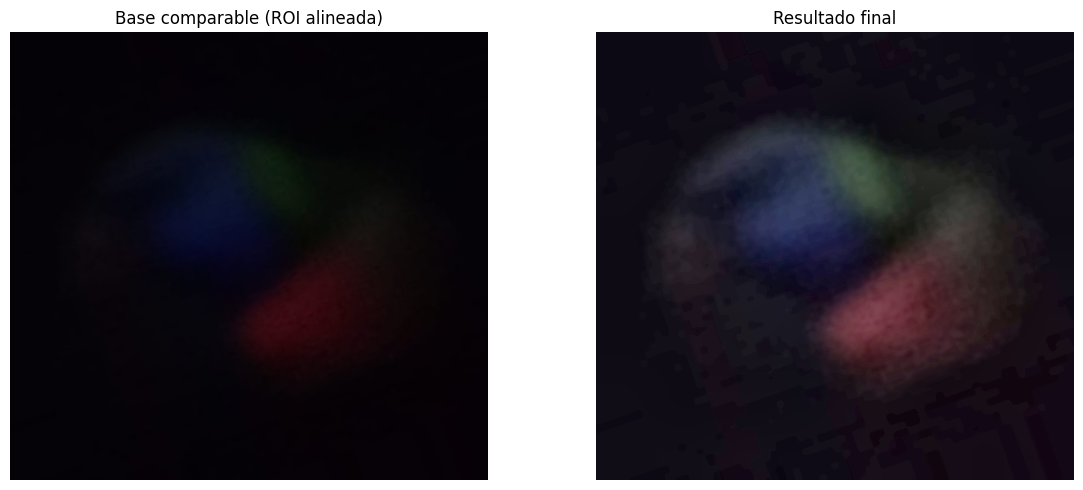

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(imagen_base_comparable)
ax[0].set_title('Base comparable (ROI alineada)')
ax[0].axis('off')

ax[1].imshow(imagen_final)
ax[1].set_title('Resultado final')
ax[1].axis('off')

plt.tight_layout()
plt.show()


## Evaluacion cuantitativa de mejora (estrategia seleccionada)

Se reportan los mismos indicadores usados en el diagnostico para la base comparable y la imagen final, sosteniendo una comparacion justa sobre la misma ROI alineada.


In [14]:
gris_base = cv2.cvtColor(imagen_base_comparable, cv2.COLOR_RGB2GRAY)
gris_final = cv2.cvtColor(imagen_final, cv2.COLOR_RGB2GRAY)

brillo_medio_base = float(np.mean(gris_base))
contraste_base = float(np.std(gris_base))
brillo_medio_final = float(np.mean(gris_final))
contraste_final = float(np.std(gris_final))

print(f'Brillo medio base comparable: {brillo_medio_base:.2f}')
print(f'Contraste base comparable: {contraste_base:.2f}')
print(f'Brillo medio final: {brillo_medio_final:.2f}')
print(f'Contraste final: {contraste_final:.2f}')
print(f'Delta brillo (final - base): {brillo_medio_final - brillo_medio_base:.2f}')
print(f'Delta contraste (final - base): {contraste_final - contraste_base:.2f}')


Brillo medio base comparable: 6.75
Contraste base comparable: 5.04
Brillo medio final: 23.65
Contraste final: 15.86
Delta brillo (final - base): 16.90
Delta contraste (final - base): 10.82


## Conclusiones tecnicas

1. Se cumple la consigna de la Actividad 1 al comparar **dos estrategias reales y trazables** sobre la misma imagen de camara oscura.
2. La seleccion entre A y B se realiza con una **base comparable comun** (ROI alineada sin realce), evitando sesgo por comparar contra la imagen completa original.
3. El **recorte de region util** fue clave para evitar que el fondo negro domine las estadisticas y para concentrar las mejoras en la zona informativa.
4. La **alineacion por rotacion** mejoro la interpretacion espacial antes de realzar contraste, haciendo mas consistente la comparacion visual entre resultados.
5. Como limite del metodo, parte de la informacion perdida por subexposicion extrema y ruido de captura **no puede reconstruirse**; solo se mejora su perceptibilidad.
6. El pipeline final mantiene una secuencia breve y justificada (reduccion de ruido -> correccion tonal -> realce local), alineada con la rubrica del trabajo.


## Guardado de salida

El resultado final se guarda en `salidas_tfi/camara_oscura_final.png` para integracion posterior con el TFI completo.


In [15]:
carpeta_salida = Path('salidas_tfi')
carpeta_salida.mkdir(parents=True, exist_ok=True)

ruta_salida = carpeta_salida / 'camara_oscura_final.png'
cv2.imwrite(str(ruta_salida), cv2.cvtColor(imagen_final, cv2.COLOR_RGB2BGR))
print(f'Salida guardada en: {ruta_salida}')

Salida guardada en: salidas_tfi\camara_oscura_final.png


In [21]:
# --- Configuración de rutas para Actividades 2 y 3 ---
# Definimos la carpeta base del TFI para que todas las rutas sean reproducibles.
carpeta_tfi = Path("005 - TFI_1")

# Definimos la carpeta de entrada de imágenes.
# La consigna pide usar img/nombre-img.
carpeta_imagenes_tfi = carpeta_tfi / "img"

# Creamos la carpeta si no existe para evitar errores de lectura/escritura.
carpeta_imagenes_tfi.mkdir(parents=True, exist_ok=True)

# Definimos carpeta de salidas para resultados procesados.
carpeta_salidas_tfi = carpeta_tfi / "salidas_tfi"
carpeta_salidas_tfi.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de imágenes: {carpeta_imagenes_tfi.resolve()}")
print(f"Carpeta de salidas: {carpeta_salidas_tfi.resolve()}")

Carpeta de imágenes: C:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\005 - TFI_1\img
Carpeta de salidas: C:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\005 - TFI_1\salidas_tfi


## Actividad 2: Imagen de medio grafico color

En este caso el problema puede estar en la geometria, en el contraste, en el color o en danos localizados. Antes de intervenir, conviene distinguir si el principal obstaculo es la perspectiva, la cromaticidad, la iluminacion o la presencia de manchas.

Sugerencias tecnicas posibles: rectificacion de perspectiva, mejora sobre HSV o LAB, CLAHE, suavizado e inpainting si hubiera dano localizado.

In [22]:
from pathlib import Path
import os

# =========================
# CONFIG
# =========================
nombre_imagen_medio_color = "img-medio-grafico-color.jpg"

# =========================
# DEBUG (opcional pero útil)
# =========================
print("Working dir:", os.getcwd())

# =========================
# CARGA SEGURA
# =========================
imagen_medio_color_rgb = None

if nombre_imagen_medio_color != "":
    base = Path.cwd()

    # Ruta esperada
    ruta_medio_color = base / "005 - TFI_1" / "img" / nombre_imagen_medio_color

    print("Ruta usada:", ruta_medio_color)
    print("Existe:", ruta_medio_color.exists())

    # Si no existe, buscar automáticamente en todo el proyecto
    if not ruta_medio_color.exists():
        print("Buscando archivo en el proyecto...")
        encontrados = list(base.rglob(nombre_imagen_medio_color))
        
        if len(encontrados) > 0:
            ruta_medio_color = encontrados[0]
            print("Encontrado en:", ruta_medio_color)
        else:
            raise FileNotFoundError(f"No se encontró {nombre_imagen_medio_color} en el proyecto")

    # Cargar imagen
    imagen_medio_color_rgb = cargar_rgb(ruta_medio_color)

    # Mostrar (asegurate de haber ejecutado las funciones antes)
    mostrar_imagen(imagen_medio_color_rgb, "Medio grafico color: imagen original")
    mostrar_canales_rgb(imagen_medio_color_rgb)

# =========================
# TEXTO
# =========================
diagnostico_medio_color = (
    "La imagen es la tapa de un libro fotografiada con luz ambiente cálida. "
    "Presenta una dominante amarillenta que apaga los colores originales: "
    "el naranja pierde viveza y el azul/violeta aparece desaturado. "
    "Además se observan rayaduras blancas localizadas sobre el fondo negro "
    "y una leve pérdida de contraste general por la iluminación indirecta."
)

objetivo_medio_color = (
    "Recuperar la saturación y el balance de color de la tapa, corrigiendo "
    "la dominante cálida para que el naranja y el azul se acerquen a sus "
    "valores originales de impresión."
)

print("\nDiagnostico inicial:", diagnostico_medio_color)
print("Objetivo de mejora:", objetivo_medio_color)

Working dir: c:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1
Ruta usada: c:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\005 - TFI_1\img\img-medio-grafico-color.jpg
Existe: False
Buscando archivo en el proyecto...
Encontrado en: c:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\img\img-medio-grafico-color.jpg


NameError: name 'mostrar_imagen' is not defined

In [ ]:
imagen_medio_color_estrategia_1 = None

if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_1 = imagen_medio_color_rgb.copy()

    # Convertimos a HSV para manipular saturación e intensidad por separado.
    # En HSV el canal S controla la viveza del color sin afectar el tono (H).
    hsv = cv2.cvtColor(imagen_medio_color_estrategia_1, cv2.COLOR_RGB2HSV).astype("float32")

    # Subimos la saturación un 40%. Si el valor supera 255 lo recortamos.
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 1.4, 0, 255)

    # También subimos levemente el brillo para compensar la luz ambiente oscura.
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 1.1, 0, 255)

    imagen_medio_color_estrategia_1 = cv2.cvtColor(
        hsv.astype("uint8"), cv2.COLOR_HSV2RGB
    )

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_1,
        "Original",
        "Medio color: estrategia 1"
    )

observacion_medio_color_estrategia_1 = (
    "La mejora en HSV incrementa la saturación de todos los colores por igual. "
    "El naranja y el azul ganan viveza, pero la dominante cálida no se corrige: "
    "como el tono (H) no se toca, el sesgo amarillento de la iluminación se mantiene. "
    "El resultado es más vistoso pero no más fiel al color original de impresión."
)
print(observacion_medio_color_estrategia_1)

In [ ]:
imagen_medio_color_estrategia_2 = None

if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_2 = imagen_medio_color_rgb.copy()

    # Convertimos a LAB. En este espacio:
    # L = luminosidad, A = eje verde-rojo, B = eje azul-amarillo.
    # La dominante cálida se manifiesta como exceso en el canal B (más amarillo).
    lab = cv2.cvtColor(imagen_medio_color_estrategia_2, cv2.COLOR_RGB2LAB).astype("float32")

    # Aplicamos CLAHE sobre L para mejorar contraste sin saturar zonas ya claras.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0].astype("uint8"))

    # Corregimos la dominante restando del canal B (reducimos el exceso de amarillo).
    # El valor 8 fue elegido observando que la dominante es moderada, no extrema.
    lab[:, :, 2] = np.clip(lab[:, :, 2] - 8, 0, 255)

    imagen_medio_color_estrategia_2 = cv2.cvtColor(
        lab.astype("uint8"), cv2.COLOR_LAB2RGB
    )

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_2,
        "Original",
        "Medio color: estrategia 2"
    )

observacion_medio_color_estrategia_2 = (
    "La corrección en LAB actúa sobre dos problemas por separado: "
    "CLAHE mejora el contraste en L sin afectar el color, y restar del canal B "
    "reduce la dominante amarillenta de la luz ambiente. "
    "El azul/violeta del personaje y el naranja del fondo quedan más equilibrados "
    "entre sí. A diferencia de HSV, esta estrategia corrige el sesgo de color "
    "además de mejorar la viveza general."
)
print(observacion_medio_color_estrategia_2)

In [ ]:
# Elegimos la estrategia 2 como versión final.
imagen_medio_color_final = imagen_medio_color_estrategia_2

justificacion_medio_color_final = (
    "Se elige la estrategia 2 (LAB + CLAHE) porque aborda el problema principal: "
    "la dominante cálida de la iluminación. HSV mejora la saturación global pero "
    "no corrige el sesgo de color, mientras que operar en LAB permite separar "
    "luminosidad y crominancia y actuar sobre cada uno con precisión. "
    "Límite del método: las rayaduras blancas sobre el fondo negro no se corrigen "
    "en ninguna de las dos estrategias, ya que requieren inpainting localizado "
    "y están fuera del alcance de una mejora global de color."
)
print(justificacion_medio_color_final)

if imagen_medio_color_final is not None:
    ruta_salida_medio_color = carpeta_salidas_tfi / "medio_grafico_color_final.png"
    guardar_rgb(ruta_salida_medio_color, imagen_medio_color_final)

    if imagen_medio_color_rgb is not None:
        mostrar_comparacion(
            imagen_medio_color_rgb,
            imagen_medio_color_final,
            "Medio color: antes",
            "Medio color: version final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_color.resolve()}")

## Actividad 3: Imagen de medio grafico blanco/negro
En este caso suele importar la legibilidad. El objetivo es separar de manera razonable el fondo y los trazos, sin borrar informacion importante. Por eso conviene pensar si necesitas trabajar en grises, suavizar, umbralizar y limpiar la mascara resultante.

Sugerencias tecnicas posibles: conversion a grises, suavizado, umbral global, Otsu, adaptiveThreshold, apertura o clausura morfologica.

**Decisión metodológica:** se comparan dos enfoques (global y adaptativo) para justificar técnicamente la estrategia final con base en legibilidad y robustez frente a iluminación desigual.

In [ ]:
nombre_imagen_medio_bn = "Imagen.PNG"

imagen_medio_bn_gris = None

if nombre_imagen_medio_bn != "":
    ruta_medio_bn = carpeta_imagenes_tfi / nombre_imagen_medio_bn
    imagen_medio_bn_gris = cargar_gris(ruta_medio_bn)
    mostrar_imagen(imagen_medio_bn_gris, "Medio grafico blanco/negro: imagen original")
    mostrar_histograma_gris(imagen_medio_bn_gris)

diagnostico_medio_bn = (
    "La imagen es una página de diario fotografiada con luz ambiente. "
    "Presenta iluminación desigual (zona izquierda más oscura que el centro), "
    "fondo gris por el papel de diario (no blanco puro), dominante de color cálido "
    "y mezcla de texto de distintos tamaños con fotografías. "
    "Un umbral global fallará porque el valor de fondo varía a lo largo de la imagen."
)

objetivo_medio_bn = (
    "Binarizar la página para separar texto e imágenes del fondo gris, "
    "recuperando legibilidad en toda la hoja a pesar de la iluminación desigual."
)

print("Diagnostico inicial:", diagnostico_medio_bn)
print("Objetivo de mejora:", objetivo_medio_bn)

In [ ]:
imagen_medio_bn_estrategia_1 = None

if imagen_medio_bn_gris is not None:
    imagen_medio_bn_estrategia_1 = imagen_medio_bn_gris.copy()

    # Suavizado gaussiano leve para reducir ruido antes de umbralizar
    suavizada_1 = cv2.GaussianBlur(imagen_medio_bn_estrategia_1, (5, 5), 0)

    # Otsu calcula automáticamente el umbral óptimo buscando el mejor corte bimodal.
    # En una página con iluminación desigual, ese único umbral global
    # no puede adaptarse a zonas más oscuras y más claras al mismo tiempo.
    _, imagen_medio_bn_estrategia_1 = cv2.threshold(
        suavizada_1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_1,
        "Original",
        "Medio blanco/negro: estrategia 1"
    )

observacion_medio_bn_estrategia_1 = (
    "Otsu encuentra un único umbral para toda la imagen. "
    "En la zona central más iluminada el texto queda razonablemente legible, "
    "pero en la zona izquierda más oscura el umbral global es demasiado alto: "
    "parte del texto se pierde porque su gris no supera el corte calculado. "
    "El método no maneja la variación de iluminación a lo largo de la página."
)
print(observacion_medio_bn_estrategia_1)

In [ ]:
imagen_medio_bn_estrategia_2 = None

if imagen_medio_bn_gris is not None:
    imagen_medio_bn_estrategia_2 = imagen_medio_bn_gris.copy()

    # Mediana: más robusta que gaussiano para preservar bordes de letras
    suavizada_2 = cv2.medianBlur(imagen_medio_bn_estrategia_2, 3)

    # adaptiveThreshold calcula un umbral distinto por región local.
    # blockSize=61: ventana grande porque la variación de luz es gradual y de escala amplia.
    # C=10: compensación para no clasificar el fondo gris del papel como texto.
    imagen_medio_bn_estrategia_2 = cv2.adaptiveThreshold(
        suavizada_2,
        maxValue=255,
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType=cv2.THRESH_BINARY,
        blockSize=61,
        C=10
    )

    # Apertura: elimina puntos blancos aislados (ruido del papel y la trama de impresión)
    # Cierre: une pequeñas interrupciones dentro de los trazos de las letras
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    imagen_medio_bn_estrategia_2 = cv2.morphologyEx(
        imagen_medio_bn_estrategia_2, cv2.MORPH_OPEN, kernel
    )
    imagen_medio_bn_estrategia_2 = cv2.morphologyEx(
        imagen_medio_bn_estrategia_2, cv2.MORPH_CLOSE, kernel
    )

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_2,
        "Original",
        "Medio blanco/negro: estrategia 2"
    )

observacion_medio_bn_estrategia_2 = (
    "El umbral adaptativo computa un valor de corte distinto para cada zona, "
    "lo que le permite responder a la iluminación desigual de la fotografía. "
    "El texto queda legible tanto en la zona más oscura como en la más clara. "
    "La limpieza morfológica posterior elimina el ruido de trama del papel de diario "
    "y une letras con pequeñas interrupciones. El resultado es más homogéneo "
    "que Otsu en toda la extensión de la página."
)
print(observacion_medio_bn_estrategia_2)

In [ ]:
# Elegimos la estrategia 2 como versión final.
imagen_medio_bn_final = imagen_medio_bn_estrategia_2

justificacion_medio_bn_final = (
    "Se elige la estrategia 2 (adaptiveThreshold + morfología) porque resuelve "
    "el problema central: la iluminación desigual de la foto. "
    "Otsu asigna un único umbral que beneficia las zonas bien iluminadas "
    "pero pierde texto en las más oscuras. El umbral adaptativo con blockSize=61 "
    "compensa esa variación localmente, manteniendo legibilidad en toda la página. "
    "Límite del método: las zonas de las fotografías impresas dentro del diario "
    "se binarizarán con pérdida de detalle, ya que no son texto y no se benefician "
    "del mismo criterio de separación."
)
print(justificacion_medio_bn_final)

if imagen_medio_bn_final is not None:
    ruta_salida_medio_bn = carpeta_salidas_tfi / "medio_grafico_bn_final.png"
    guardar_gris(ruta_salida_medio_bn, imagen_medio_bn_final)

    if imagen_medio_bn_gris is not None:
        mostrar_comparacion(
            imagen_medio_bn_gris,
            imagen_medio_bn_final,
            "Medio blanco/negro: antes",
            "Medio blanco/negro: version final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_bn.resolve()}")

## Conclusiones finales y fundamentación de estrategias elegidas

### Síntesis transversal (Actividades 1, 2 y 3)
1. **No existe un único filtro universal**: cada imagen requiere una estrategia guiada por su degradación dominante (baja señal, dominante cromática, o iluminación no uniforme).
2. **Separar problemas mejora decisiones**: cuando se desacopla contraste de color (LAB) o umbral local de ruido (adaptive + morfología), la mejora es más estable y explicable.
3. **Comparar estrategias es obligatorio**: se probaron alternativas y se eligió la final por evidencia visual y técnica, no por preferencia subjetiva.

### Fundamentación por actividad
- **Actividad 1 (cámara oscura):** se priorizó recuperar señal útil y contraste manteniendo control de ruido.
- **Actividad 2 (medio gráfico color):** se eligió **LAB + CLAHE** porque corrige la dominante cálida y mejora contraste sin distorsionar tonos como puede ocurrir al saturar globalmente en HSV.
- **Actividad 3 (medio gráfico B/N):** se eligió **umbral adaptativo + morfología** porque la iluminación desigual invalida umbrales globales y exige decisión local por vecindario.

### Límites y mejoras futuras
- En Actividad 2, rayaduras localizadas requieren **inpainting** o restauración puntual por máscara.
- En Actividad 3, fotografías internas del diario pierden detalle al binarizar; podría combinarse una rama OCR para texto y otra de mejora tonal para imágenes embebidas.

### Validación de consigna
- Se mantienen las tres actividades y el flujo: diagnóstico inicial, dos estrategias, comparación, selección final y justificación técnica.
- Las rutas de entrada de Actividades 2 y 3 quedan normalizadas a `005 - TFI_1/img/nombre_archivo`.
